In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
%matplotlib inline
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('datos.csv')

print("Primeras 5 filas del dataset:")
display(df.head())

print("\nInformación del DataFrame:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

Primeras 5 filas del dataset:


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7032 non-null   object 
 1   Evasion                  7032 non-null   object 
 2   Genero                   7032 non-null   object 
 3   Adulto_Mayor             7032 non-null   int64  
 4   Pareja                   7032 non-null   object 
 5   Dependientes             7032 non-null   object 
 6   Meses_Contrato           7032 non-null   int64  
 7   Servicio_Telefonico      7032 non-null   object 
 8   Multiples_Lineas         7032 non-null   object 
 9   Servicio_Internet        7032 non-null   object 
 10  Seguridad_Online         7032 non-null   object 
 11  Respaldo_Online          7032 non-null   object 
 12  Proteccion_Dispositivo   7032 non-null   object 
 13  Soporte_Tecnico          7032 non-null   object 
 

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [4]:
df.drop('ID_Cliente', axis=1, inplace=True)

print("Columnas actuales:")
print(df.columns.tolist())

print("\nPrimeras 5 filas sin ID_Cliente:")
display(df.head())

Columnas actuales:
['Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

Primeras 5 filas sin ID_Cliente:


,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [5]:
X = df.drop('Evasion', axis=1)
y = df['Evasion'].map({'Yes': 1, 'No': 0})

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas:", categorical_cols)

binary_cols = []
multi_cols = []
for col in categorical_cols:
    if X[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print("\nVariables binarias (mapeo a 0/1):", binary_cols)
print("Variables con múltiples categorías (one-hot encoding):", multi_cols)

for col in binary_cols:
    unique_vals = X[col].unique()
    if set(unique_vals) == {'Yes', 'No'}:
        X[col] = X[col].map({'Yes': 1, 'No': 0})
    else:
        print(f"La columna {col} tiene valores inesperados: {unique_vals}")

X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

print("\nDimensiones del DataFrame después de encoding:", X.shape)
print("Primeras filas de X:")
display(X.head())

print("\nVariable objetivo (y):")
print(y.head())

Columnas categóricas: ['Genero', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Electronica', 'Metodo_Pago']

Variables binarias (mapeo a 0/1): ['Genero', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Facturacion_Electronica']
Variables con múltiples categorías (one-hot encoding): ['Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Metodo_Pago']
La columna Genero tiene valores inesperados: ['Female' 'Male']

Dimensiones del DataFrame después de encoding: (7032, 31)
Primeras filas de X:


,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,Female,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,True,False,False,False,True
1,Male,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,False,False,False,True
2,Male,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,False,False,True,False
3,Male,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,False,True,False,False,False,True,False
4,Female,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,True,False,False,False,False,False,False,True



Variable objetivo (y):
0    0
1    0
2    1
3    1
4    1
Name: Evasion, dtype: int64


In [6]:
X['Genero'] = X['Genero'].map({'Female': 0, 'Male': 1})

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

print("Tipos de datos después de correcciones:")
print(X.dtypes.value_counts())

print("\nPrimeras filas de X corregido:")
display(X.head())

print("\nValores nulos en X:", X.isnull().sum().sum())
print("Valores nulos en y:", y.isnull().sum())

Tipos de datos después de correcciones:
int64      28
float64     3
Name: count, dtype: int64

Primeras filas de X corregido:


,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,...,Soporte_Tecnico_Yes,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Peliculas_No internet service,Streaming_Peliculas_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,1,0,1,0,0,1,0,0,0,1
1,1,0,0,0,9,1,0,59.9,542.40,2.00,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,0,0,1,0,1,0,0,0,1,0
4,0,1,1,0,3,1,1,83.9,267.40,2.80,...,1,0,1,0,0,0,0,0,0,1



Valores nulos en X: 0
Valores nulos en y: 0


Conteo de clases:
0 (No canceló): 5163
1 (Canceló): 1869

Proporción (%):
0 (No canceló): 73.42%
1 (Canceló): 26.58%


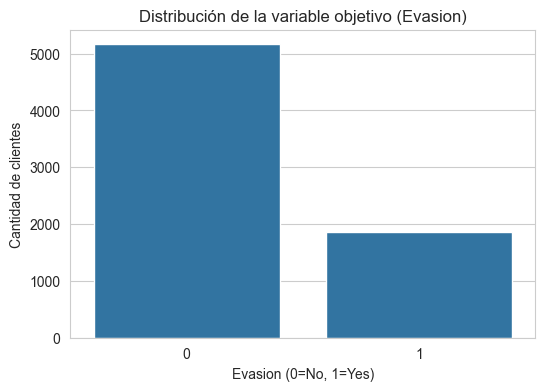

In [7]:
churn_counts = y.value_counts()
churn_proportions = y.value_counts(normalize=True) * 100

print("Conteo de clases:")
print(f"0 (No canceló): {churn_counts[0]}")
print(f"1 (Canceló): {churn_counts[1]}")
print("\nProporción (%):")
print(f"0 (No canceló): {churn_proportions[0]:.2f}%")
print(f"1 (Canceló): {churn_proportions[1]:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Distribución de la variable objetivo (Evasion)')
plt.xlabel('Evasion (0=No, 1=Yes)')
plt.ylabel('Cantidad de clientes')
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Distribución original en entrenamiento:")
print(y_train.value_counts())
print(f"Proporción: {y_train.value_counts(normalize=True).values*100}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE en entrenamiento:")
print(y_train_res.value_counts())
print(f"Proporción: {y_train_res.value_counts(normalize=True).values*100}")

print(f"\nDimensiones originales X_train: {X_train.shape}")
print(f"Dimensiones después SMOTE X_train_res: {X_train_res.shape}")

Distribución original en entrenamiento:
Evasion
0    3614
1    1308
Name: count, dtype: int64
Proporción: [73.42543681 26.57456319]

Distribución después de SMOTE en entrenamiento:
Evasion
1    3614
0    3614
Name: count, dtype: int64
Proporción: [50. 50.]

Dimensiones originales X_train: (4922, 31)
Dimensiones después SMOTE X_train_res: (7228, 31)


Correlación de características con Evasion:
Servicio_Internet_Fiber optic                 0.307463
Metodo_Pago_Electronic check                  0.301455
Cuentas_Diarias                               0.192914
Cargos_Mensuales                              0.192858
Facturacion_Electronica                       0.191454
Adulto_Mayor                                  0.150541
Streaming_TV_Yes                              0.063254
Streaming_Peliculas_Yes                       0.060860
Multiples_Lineas_Yes                          0.040033
Servicio_Telefonico                           0.011691
Genero                                       -0.008545
Multiples_Lineas_No phone service            -0.011691
Proteccion_Dispositivo_Yes                   -0.066193
Respaldo_Online_Yes                          -0.082307
Metodo_Pago_Mailed check                     -0.090773
Metodo_Pago_Credit card (automatic)          -0.134687
Pareja                                       -0.149982
Dependientes         

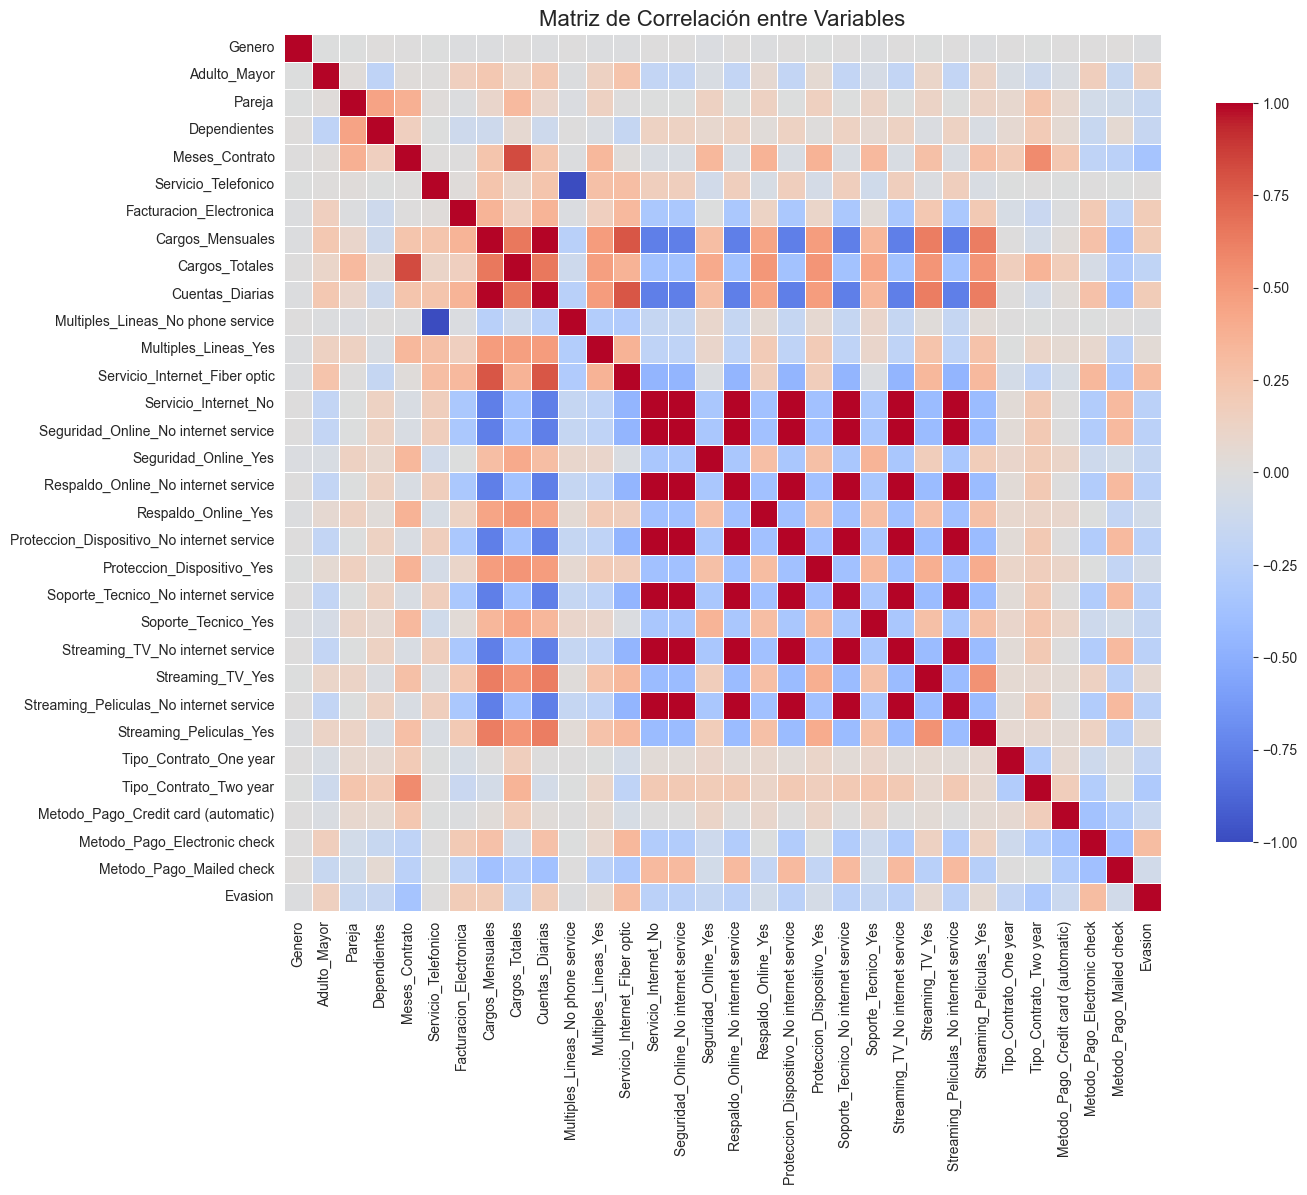

In [9]:
df_corr = X.copy()
df_corr['Evasion'] = y

corr_matrix = df_corr.corr()

corr_with_target = corr_matrix['Evasion'].drop('Evasion').sort_values(ascending=False)
print("Correlación de características con Evasion:")
print(corr_with_target)

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables', fontsize=16)
plt.tight_layout()
plt.show()

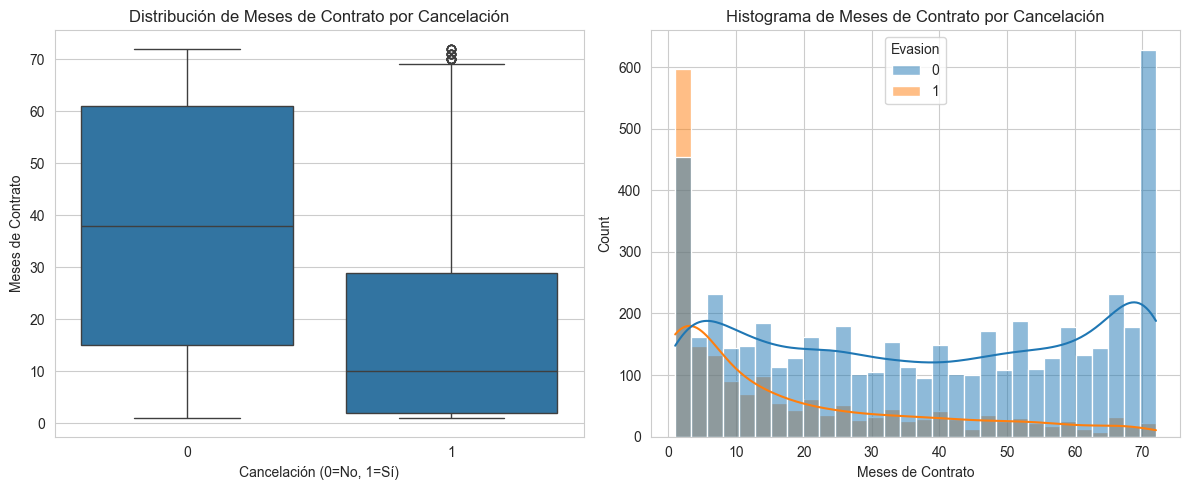

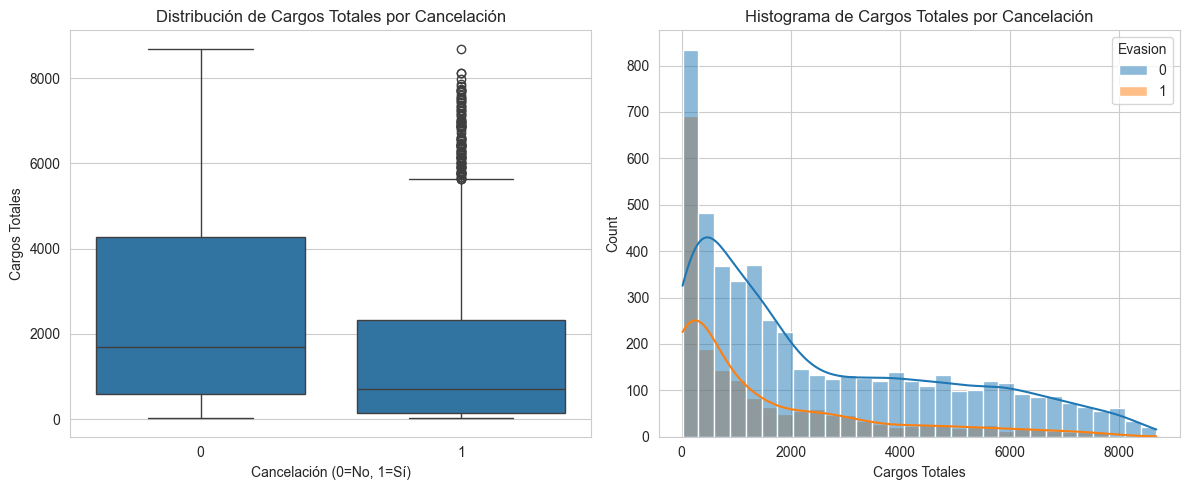

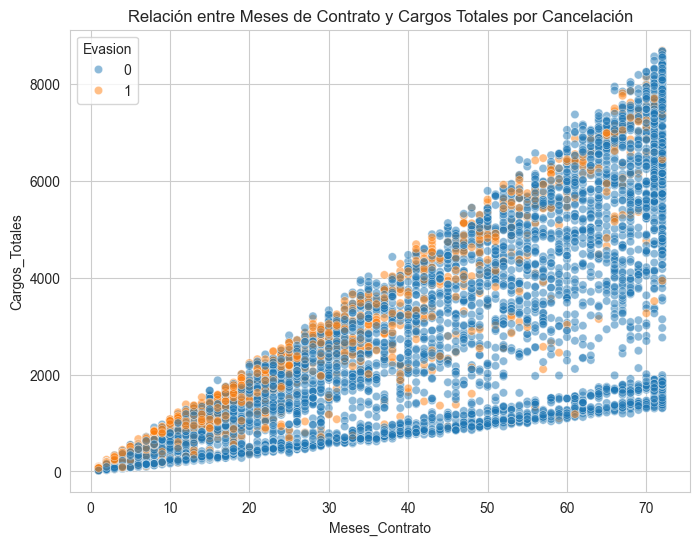

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=y, y=X['Meses_Contrato'])
plt.title('Distribución de Meses de Contrato por Cancelación')
plt.xlabel('Cancelación (0=No, 1=Sí)')
plt.ylabel('Meses de Contrato')

plt.subplot(1,2,2)
sns.histplot(data=df_corr, x='Meses_Contrato', hue='Evasion', kde=True, bins=30)
plt.title('Histograma de Meses de Contrato por Cancelación')
plt.xlabel('Meses de Contrato')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=y, y=X['Cargos_Totales'])
plt.title('Distribución de Cargos Totales por Cancelación')
plt.xlabel('Cancelación (0=No, 1=Sí)')
plt.ylabel('Cargos Totales')

plt.subplot(1,2,2)
sns.histplot(data=df_corr, x='Cargos_Totales', hue='Evasion', kde=True, bins=30)
plt.title('Histograma de Cargos Totales por Cancelación')
plt.xlabel('Cargos Totales')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_corr, x='Meses_Contrato', y='Cargos_Totales', hue='Evasion', alpha=0.5)
plt.title('Relación entre Meses de Contrato y Cargos Totales por Cancelación')
plt.show()

In [11]:
print("Tamaño del conjunto de entrenamiento original:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("\nDistribución en entrenamiento original:")
print(y_train.value_counts(normalize=True))
print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

print("\nTamaño del conjunto de entrenamiento balanceado con SMOTE:", X_train_res.shape)
print("Distribución en entrenamiento balanceado:")
print(y_train_res.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento original: (4922, 31)
Tamaño del conjunto de prueba: (2110, 31)

Distribución en entrenamiento original:
Evasion
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Distribución en prueba:
Evasion
0    0.734123
1    0.265877
Name: proportion, dtype: float64

Tamaño del conjunto de entrenamiento balanceado con SMOTE: (7228, 31)
Distribución en entrenamiento balanceado:
Evasion
1    0.5
0    0.5
Name: proportion, dtype: float64


In [12]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
print("Modelo 1: Regresión Logística con normalización (entrenado con datos originales)")

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
print("Modelo 2: Random Forest sin normalización (entrenado con datos originales)")

lr_pipeline_res = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline_res.fit(X_train_res, y_train_res)
print("\nRegresión Logística entrenada con datos balanceados (SMOTE)")

rf_model_res = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_res.fit(X_train_res, y_train_res)
print("Random Forest entrenado con datos balanceados (SMOTE)")

Modelo 1: Regresión Logística con normalización (entrenado con datos originales)
Modelo 2: Random Forest sin normalización (entrenado con datos originales)

Regresión Logística entrenada con datos balanceados (SMOTE)
Random Forest entrenado con datos balanceados (SMOTE)


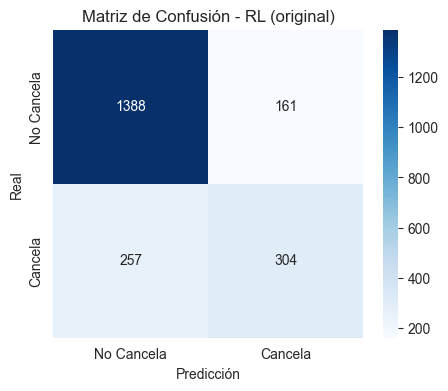


--- RL (original) ---
              precision    recall  f1-score   support

  No Cancela       0.84      0.90      0.87      1549
     Cancela       0.65      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



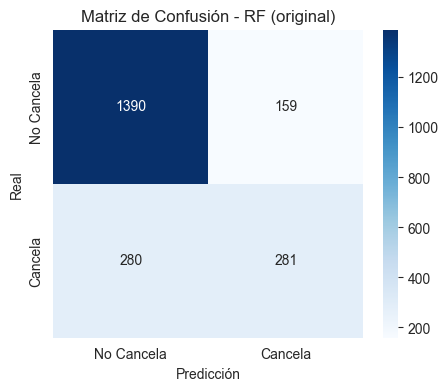


--- RF (original) ---
              precision    recall  f1-score   support

  No Cancela       0.83      0.90      0.86      1549
     Cancela       0.64      0.50      0.56       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



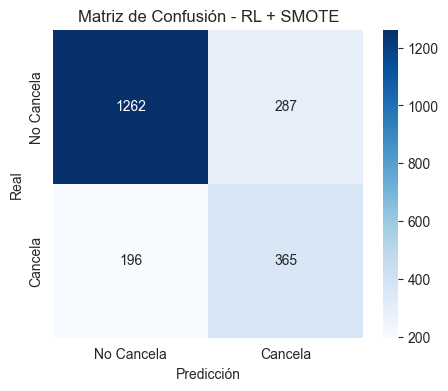


--- RL + SMOTE ---
              precision    recall  f1-score   support

  No Cancela       0.87      0.81      0.84      1549
     Cancela       0.56      0.65      0.60       561

    accuracy                           0.77      2110
   macro avg       0.71      0.73      0.72      2110
weighted avg       0.78      0.77      0.78      2110



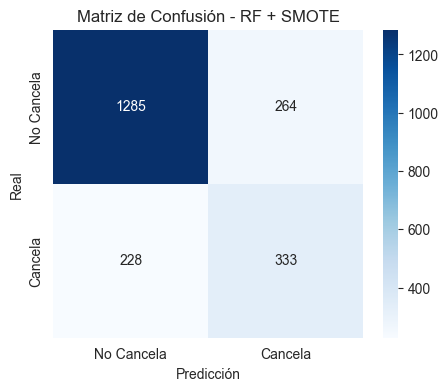


--- RF + SMOTE ---
              precision    recall  f1-score   support

  No Cancela       0.85      0.83      0.84      1549
     Cancela       0.56      0.59      0.58       561

    accuracy                           0.77      2110
   macro avg       0.70      0.71      0.71      2110
weighted avg       0.77      0.77      0.77      2110


--- RESUMEN COMPARATIVO ---
       Modelo  Exactitud  Precisión   Recall  F1-score
RL (original)   0.801896   0.653763 0.541889  0.592593
RF (original)   0.791943   0.638636 0.500891  0.561439
   RL + SMOTE   0.771090   0.559816 0.650624  0.601814
   RF + SMOTE   0.766825   0.557789 0.593583  0.575130

--- ANÁLISIS DE OVERFITTING ---
RL (original): Exactitud en entrenamiento = 0.8082, en prueba = 0.8019, diferencia = 0.0063
  → Bien balanceado
RF (original): Exactitud en entrenamiento = 0.9986, en prueba = 0.7919, diferencia = 0.2066
  → Posible overfitting (diferencia > 0.1)
RL + SMOTE: Exactitud en entrenamiento = 0.8380, en prueba = 0.7711, 

In [13]:
modelos = [
    ('RL (original)', lr_pipeline),
    ('RF (original)', rf_model),
    ('RL + SMOTE', lr_pipeline_res),
    ('RF + SMOTE', rf_model_res)
]

resultados = []

for nombre, modelo in modelos:
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    resultados.append({
        'Modelo': nombre,
        'Exactitud': acc,
        'Precisión': prec,
        'Recall': rec,
        'F1-score': f1
    })
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Cancela', 'Cancela'], yticklabels=['No Cancela', 'Cancela'])
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=['No Cancela', 'Cancela']))

df_resultados = pd.DataFrame(resultados)
print("\n--- RESUMEN COMPARATIVO ---")
print(df_resultados.to_string(index=False))

print("\n--- ANÁLISIS DE OVERFITTING ---")
for nombre, modelo in modelos:
    if 'SMOTE' in nombre:
        train_pred = modelo.predict(X_train_res)
        train_acc = accuracy_score(y_train_res, train_pred)
    else:
        train_pred = modelo.predict(X_train)
        train_acc = accuracy_score(y_train, train_pred)
    
    test_acc = accuracy_score(y_test, modelo.predict(X_test))
    diff = train_acc - test_acc
    print(f"{nombre}: Exactitud en entrenamiento = {train_acc:.4f}, en prueba = {test_acc:.4f}, diferencia = {diff:.4f}")
    if diff > 0.1:
        print("  → Posible overfitting (diferencia > 0.1)")
    elif diff < -0.05:
        print("  → Posible underfitting (prueba mejor que entrenamiento, inusual)")
    else:
        print("  → Bien balanceado")

=== REGRESIÓN LOGÍSTICA (ORIGINAL) - COEFICIENTES ===
Los coeficientes positivos aumentan la probabilidad de cancelación; negativos la disminuyen.

                     Variable  Coeficiente  Abs_Coef
               Meses_Contrato    -1.355178  1.355178
Servicio_Internet_Fiber optic     0.657162  0.657162
               Cargos_Totales     0.638840  0.638840
       Tipo_Contrato_Two year    -0.542827  0.542827
             Cargos_Mensuales    -0.351520  0.351520
              Cuentas_Diarias    -0.314827  0.314827
       Tipo_Contrato_One year    -0.284569  0.284569
             Streaming_TV_Yes     0.226222  0.226222
 Metodo_Pago_Electronic check     0.184343  0.184343
      Facturacion_Electronica     0.180571  0.180571
      Streaming_Peliculas_Yes     0.180500  0.180500
         Multiples_Lineas_Yes     0.141809  0.141809
          Soporte_Tecnico_Yes    -0.138539  0.138539
                 Adulto_Mayor     0.094930  0.094930
         Seguridad_Online_Yes    -0.085143  0.085143


==

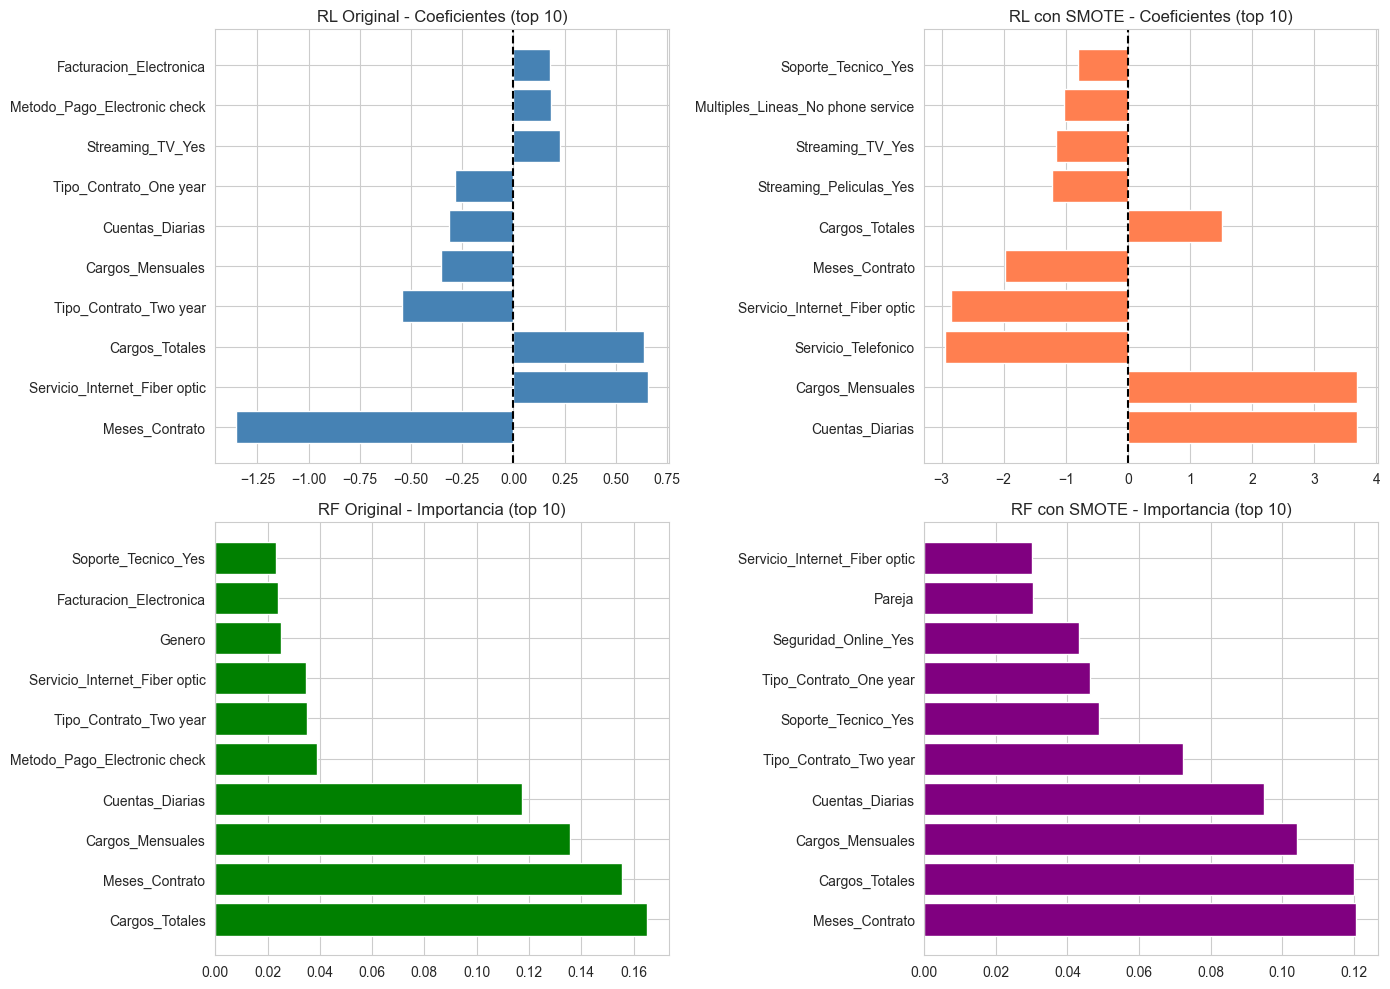

In [14]:
lr_original = lr_pipeline.named_steps['lr']
coef_original = lr_original.coef_[0]
nombres = X.columns

coef_df_original = pd.DataFrame({
    'Variable': nombres,
    'Coeficiente': coef_original,
    'Abs_Coef': np.abs(coef_original)
}).sort_values('Abs_Coef', ascending=False)

print("=== REGRESIÓN LOGÍSTICA (ORIGINAL) - COEFICIENTES ===")
print("Los coeficientes positivos aumentan la probabilidad de cancelación; negativos la disminuyen.\n")
print(coef_df_original.head(15).to_string(index=False))

lr_smote = lr_pipeline_res.named_steps['lr']
coef_smote = lr_smote.coef_[0]
coef_df_smote = pd.DataFrame({
    'Variable': nombres,
    'Coeficiente': coef_smote,
    'Abs_Coef': np.abs(coef_smote)
}).sort_values('Abs_Coef', ascending=False)

print("\n\n=== REGRESIÓN LOGÍSTICA (CON SMOTE) - COEFICIENTES ===")
print(coef_df_smote.head(15).to_string(index=False))

importancia_rf_orig = rf_model.feature_importances_
importancia_df_orig = pd.DataFrame({
    'Variable': nombres,
    'Importancia': importancia_rf_orig
}).sort_values('Importancia', ascending=False)

print("\n\n=== RANDOM FOREST (ORIGINAL) - IMPORTANCIA DE VARIABLES ===")
print(importancia_df_orig.head(15).to_string(index=False))

importancia_rf_smote = rf_model_res.feature_importances_
importancia_df_smote = pd.DataFrame({
    'Variable': nombres,
    'Importancia': importancia_rf_smote
}).sort_values('Importancia', ascending=False)

print("\n\n=== RANDOM FOREST (CON SMOTE) - IMPORTANCIA DE VARIABLES ===")
print(importancia_df_smote.head(15).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RL original
axes[0,0].barh(coef_df_original.head(10)['Variable'], coef_df_original.head(10)['Coeficiente'], color='steelblue')
axes[0,0].set_title('RL Original - Coeficientes (top 10)')
axes[0,0].axvline(0, color='black', linestyle='--')

# RL SMOTE
axes[0,1].barh(coef_df_smote.head(10)['Variable'], coef_df_smote.head(10)['Coeficiente'], color='coral')
axes[0,1].set_title('RL con SMOTE - Coeficientes (top 10)')
axes[0,1].axvline(0, color='black', linestyle='--')

# RF original
axes[1,0].barh(importancia_df_orig.head(10)['Variable'], importancia_df_orig.head(10)['Importancia'], color='green')
axes[1,0].set_title('RF Original - Importancia (top 10)')

# RF SMOTE
axes[1,1].barh(importancia_df_smote.head(10)['Variable'], importancia_df_smote.head(10)['Importancia'], color='purple')
axes[1,1].set_title('RF con SMOTE - Importancia (top 10)')

plt.tight_layout()
plt.show()

## 📋 Conclusión

Después de desarrollar y evaluar cuatro modelos predictivos (Regresión Logística y Random Forest, con y sin balanceo SMOTE), se han identificado los principales factores que influyen en la cancelación de clientes (churn) de Telecom X. A continuación se presenta un análisis integrado de los resultados, junto con recomendaciones accionables para el área de retención.

### 1. Rendimiento de los Modelos

| Modelo               | Exactitud | Precisión | Recall | F1-score | Observaciones |
|----------------------|-----------|-----------|--------|----------|---------------|
| RL (original)        | 80.2%     | 65.4%     | 54.2%  | 0.593    | Mejor equilibrio general |
| RF (original)        | 79.2%     | 63.9%     | 50.1%  | 0.561    | Overfitting severo (99.9% en train) |
| RL + SMOTE           | 77.1%     | 56.0%     | 65.1%  | 0.602    | Mayor recall, menor precisión |
| RF + SMOTE           | 76.7%     | 55.8%     | 59.4%  | 0.575    | Overfitting persistente |

- **Mejor modelo en términos de F1-score:** RL + SMOTE (0.602), aunque sacrifica exactitud general.  
- **Mejor modelo para identificar correctamente a los que cancelan (recall):** RL + SMOTE (65.1%), clave para acciones preventivas.  
- **Problema de overfitting:** Random Forest alcanza ~99.9% de exactitud en entrenamiento, indicando que memoriza los datos y no generaliza bien. Se recomienda podar los árboles o reducir su complejidad (ej. limitar profundidad, aumentar min_samples_split).

### 2. Factores Clave que Influyen en la Cancelación

Los coeficientes de la regresión logística y la importancia de variables del Random Forest coinciden en señalar los siguientes patrones:

| Factor | Dirección | Interpretación |
|--------|-----------|----------------|
| **Meses_Contrato** | Negativa | Clientes con mayor antigüedad tienen menor probabilidad de cancelar. |
| **Cargos_Totales** | Positiva | A mayor gasto acumulado, mayor riesgo de cancelación (posiblemente porque son clientes de más tiempo, pero la relación es compleja). |
| **Servicio_Internet_Fiber optic** | Positiva | Clientes con fibra óptica cancelan más que los de DSL o sin internet. |
| **Tipo_Contrato (Two year / One year)** | Negativa | Contratos más largos reducen drásticamente el churn. |
| **Cuentas_Diarias / Cargos_Mensuales** | Variable | En RL original tienen signo negativo, pero en RL+SMOTE se vuelven positivos (por la interacción con otras variables). Indican que clientes con cargos altos o muchas cuentas diarias requieren análisis más fino. |
| **Método de pago: Electronic check** | Positiva | Quienes pagan con cheque electrónico son más propensos a cancelar que los que usan domiciliación o tarjeta. |
| **Facturación Electrónica** | Positiva | Puede estar asociada a perfiles más digitales pero también menos fidelizados. |
| **Servicios adicionales (Soporte_Técnico, Seguridad_Online, etc.)** | Mixto | En general, tener servicios de valor agregado (como soporte técnico) reduce el churn, aunque con coeficientes pequeños. |

### 3. Estrategias de Retención Basadas en Datos

Con base en los factores identificados, se proponen las siguientes acciones:

#### a) Incentivar Contratos de Largo Plazo
- Ofrecer descuentos o beneficios exclusivos para clientes que acepten contratos de uno o dos años.
- Comunicar las ventajas de la permanencia (precios fijos, soporte prioritario).

#### b) Intervenir en Clientes con Servicio de Fibra Óptica
- Realizar encuestas de satisfacción específicas para usuarios de fibra óptica.
- Revisar la calidad del servicio (velocidad, estabilidad) y ofrecer mejoras o compensaciones proactivas.

#### c) Atención a Clientes con Alto Gasto Acumulado
- Segmentar a clientes con altos `Cargos_Totales` (por encima del percentil 75) y contactarlos para ofrecer programas de fidelización.
- Analizar si el alto gasto se debe a servicios premium y si estos realmente agregan valor percibido.

#### d) Modificar Métodos de Pago
- Promover la domiciliación bancaria o tarjeta de crédito (que tienen menor churn) mediante pequeños incentivos (ej. descuento del 2% en la factura).
- Identificar por qué el cheque electrónico se asocia a mayor cancelación (quizás por falta de automatización o percepción de inseguridad).

#### e) Potenciar Servicios de Soporte y Seguridad
- Incluir en campañas de marketing la disponibilidad de soporte técnico y seguridad online como elementos que reducen el churn.
- Ofrecer pruebas gratuitas de estos servicios a clientes en riesgo.

### 4. Limitaciones y Próximos Pasos

- **Overfitting en Random Forest:** Ajustar hiperparámetros (max_depth, min_samples_leaf) o utilizar validación cruzada más robusta.
- **Balanceo con SMOTE:** Mejoró el recall pero redujo precisión; se podría probar otras técnicas (SMOTE-Tomek, ajuste de pesos de clase).
- **Variables no consideradas:** Datos de interacciones con atención al cliente, reclamaciones, uso real de servicios. Incorporar estas fuentes podría mejorar la precisión.

---

**Conclusión Final:**  
El cliente tipo que cancela tiene contrato mensual, paga con cheque electrónico, usa fibra óptica y tiene un gasto total elevado. La estrategia de retención debe enfocarse en **alargar contratos, mejorar la experiencia de fibra óptica y promover métodos de pago automáticos**. Con estos insights, Telecom X puede anticiparse al churn y diseñar campañas más efectivas.